# Clustering de Supervivencia en Contratos de Energía Eléctrica

**TFG — Diego Suárez | Tutor: Luciano**

---

Este notebook aplica el método **RSF-PHATE** al dataset anonimizado de contratos de
electricidad para identificar grupos de clientes con comportamientos de churn distintos.

### ¿Por qué análisis de supervivencia?

La pregunta clásica de churn es: *¿se irá o no este cliente?* (clasificación binaria).
El análisis de supervivencia va un paso más allá y pregunta: *¿cuánto tiempo se quedará?*

Esto nos permite trabajar con **censura a la derecha**: los clientes que siguen activos
no los descartamos — sabemos que llevan *k* días sin irse, lo que también es información.

| Variable | Columna en el CSV | Significado |
|----------|-------------------|-------------|
| `time`   | `ANTIGUEDAD_CLIENTE` | Días que lleva / llevó activo el contrato (ANTIGUEDAD_CLIENTE está en días) |
| `event`  | `TARGET` (bool)   | `True` = el cliente se dio de baja (churn real) |
| `X`      | resto de columnas | Covariables: consumo, canal, tipo de oferta… |

### Pipeline RSF-PHATE

```
X, time, event
    ↓
1. Random Survival Forest → matriz de proximidad basada en rutas de árbol
    ↓
2. Suavizado por difusión (heat kernel) → refuerza estructura global
    ↓
3. Embedding PHATE → representación 2D fiel a la geometría de supervivencia
    ↓
4. Clustering espectral (Yu-Shi) → etiquetas de cluster
    ↓
labels_, embedding_
```

## 0. Imports y configuración global

In [ ]:
# ── Librerías estándar ───────────────────────────────────────────────────────
import sys
import os
import warnings
import numpy as np
import pandas as pd

# ── Visualización ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

# ── Análisis de supervivencia ────────────────────────────────────────────────
from sksurv.nonparametric import kaplan_meier_estimator  # curvas K-M
from sksurv.linear_model import CoxPHSurvivalAnalysis    # baseline
from sklearn.cluster import KMeans                       # baseline

# ── Nuestro modelo principal ─────────────────────────────────────────────────
# RSFPhate: el estimador principal
# to_survival_array: convierte (time, event) al formato de scikit-survival
from rsfphate import RSFPhate, to_survival_array

# ── Módulo de preprocesado propio ─────────────────────────────────────────────
# Añadimos la carpeta examples/ al path para poder importar churn_preprocessing.py
# (el fichero está en rsfphate/examples/ y este notebook en rsfphate/notebooks/)
sys.path.insert(0, os.path.abspath(os.path.join('..', 'examples')))
from churn_preprocessing import (
    cargar_datos,
    preparar_muestra_supervivencia,
    preprocesar_supervivencia,
)

# ── Configuración global ─────────────────────────────────────────────────────
RANDOM_STATE = 42           # semilla para reproducibilidad
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')  # silenciamos avisos de convergencia menores

print('Imports OK')

Imports OK


## 1. Carga y exploración inicial del dataset

El fichero `datos_anonimizados.csv` contiene **678.750 contratos** de electricidad.
Cada fila es una observación con sus características en un momento de corte y una
etiqueta `TARGET=1` si el cliente terminó dándose de baja.

In [ ]:
# Ruta al CSV — desde la carpeta notebooks/ subimos dos niveles hasta TFG/
# y luego entramos en ClusterScripts/
DATA_PATH = os.path.abspath(
    os.path.join('..', '..', 'ClusterScripts', 'datos_anonimizados.csv')
)

# cargar_datos() lee el CSV y muestra un resumen automáticamente
df_raw = cargar_datos(DATA_PATH)

Datos cargados:          678,750 filas × 54 columnas
Clientes con churn:       48,360  (7.12%)
Clientes sin churn:      630,390  (92.88%)


In [ ]:
# Primeras filas para ver la estructura de los datos
print(f'Columnas ({df_raw.shape[1]}):',  list(df_raw.columns))
display(df_raw.head(3))

Columnas (54): ['ACCESOS_AC_ML_3MESES_MOD', 'ANTIG_CLI_RANGO', 'ANTIGUEDAD', 'ANTIGUEDAD_CLIENTE', 'CANAL_INPUT', 'CANJE_PUNTOS_FECHA_REF_3_BIN', 'CARTERA_MEDIA', 'CHURN_COD_POSTAL', 'DESC_TV_MOD', 'DIAS_FIN_PROMO', 'DIAS_FIN_PROMO_RANGO', 'DIAS_PARA_RENOVAR', 'DIAS_PARA_RENOVAR_MOD', 'DIAS_ULTIMA_FACTURA', 'EFACTURA', 'FACTURACION_ALTA', 'FECHA_ALTA_INSTALACION', 'FECHA_BAJA_INSTALACION', 'IMP_CONSUMO_ACTIVA_MOD', 'IMP_DEUDA_VENCIDA', 'IMP_PRECIO_MAX', 'IND_Alta_Adva', 'N_ATC_FECHA_REF_3_MOD', 'N_CONTACTO_FECHA_REF_1', 'N_CONTACTO_FECHA_REF_2', 'N_CONTACTO_FECHA_REF_3', 'N_CTOS_ACTIVOS_IC', 'N_CTOS_BAJA_UMES_IC_MOD', 'N_FACILITA_FECHA_REF_3_MOD', 'N_FACT_COBR_FECHA_REF_3_MOD', 'N_GESTION_FECHA_REF_3_MOD', 'N_OOSS_ASIST_MOD', 'N_OOSS_MANT_MOD', 'N_OOSS_SSAA_MOD', 'N_ORDENES_SERVICIO_MOD', 'N_PEDIDOINFO_FECHA_REF_3_BIN', 'N_PEDIDOINFO_FECHA_REF_3_MOD', 'N_RECLAM_FECHA_REF_3_MOD', 'N_VENTAS_CONT_FECHA_REF_3_MOD', 'NUM_CONTRATO', 'NUM_CTOS_01_MOD', 'NUM_CTOS_02_MOD', 'NUM_CTOS_05_MOD', 'N

,ACCESOS_AC_ML_3MESES_MOD,ANTIG_CLI_RANGO,ANTIGUEDAD,ANTIGUEDAD_CLIENTE,CANAL_INPUT,CANJE_PUNTOS_FECHA_REF_3_BIN,CARTERA_MEDIA,CHURN_COD_POSTAL,DESC_TV_MOD,DIAS_FIN_PROMO,...,NUM_CTOS_L2_MOD,PROVINCIA_AGR,PROVINCIA_PS,RENOVACION_CAPTACION_MOD,SUBCANAL_INPUT,NBAJAS_36M_MOD,N_ALTAS_L1_IC,GEN_MOD,COD_SEXO,TARGET
0,0,6,6488,6505,CANAL 1,0,9948.0,0.014274,4,NaN,...,1,PROVINCIA_AGR 1,PROVINCIA 1,TRIMESTRAL,SUBCANAL 1,0,2,V,N,1
1,1,6,6485,6505,CANAL 1,0,5665.5,0.012885,0,NaN,...,2,PROVINCIA_AGR 1,PROVINCIA 1,TRIMESTRAL,SUBCANAL 1,0,2,V,V,0
2,0,6,6485,6505,CANAL 1,0,5360.5,0.014364,7,1021.0,...,1,PROVINCIA_AGR 1,PROVINCIA 1,RENOVACION,SUBCANAL 1,0,1,V,V,0


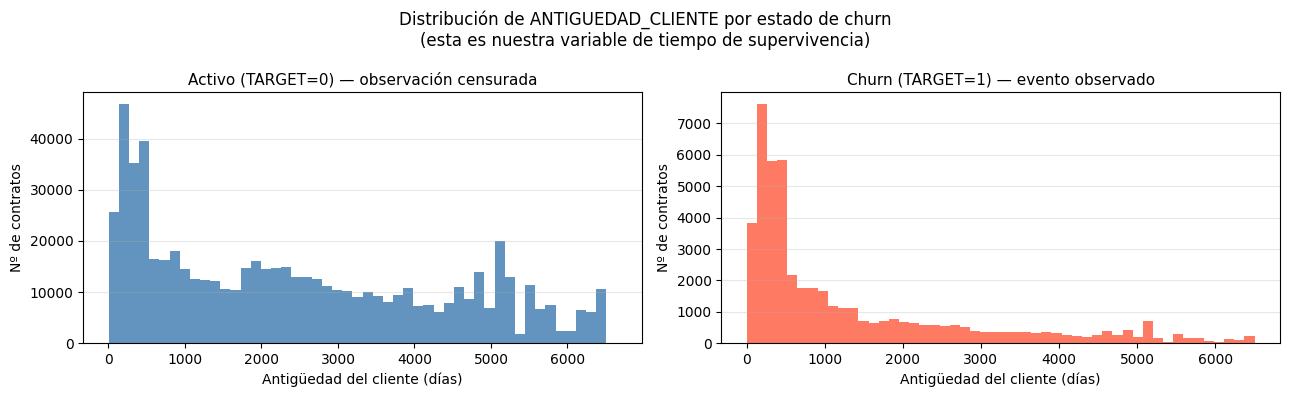

In [ ]:
# Distribución de la variable de tiempo (ANTIGUEDAD_CLIENTE)
# separada por clientes que churnearon vs. los que siguen activos.
# Esto nos da una primera intuición de los patrones de supervivencia.

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, target_val, label, color in zip(
    axes,
    [0, 1],
    ['Activo (TARGET=0) — observación censurada', 'Churn (TARGET=1) — evento observado'],
    ['steelblue', 'tomato'],
):
    mask = df_raw['TARGET'] == target_val
    ax.hist(
        df_raw.loc[mask, 'ANTIGUEDAD_CLIENTE'],
        bins=50, color=color, alpha=0.85, edgecolor='none',
    )
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Antigüedad del cliente (días)', fontsize=10)
    ax.set_ylabel('Nº de contratos', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(
    'Distribución de ANTIGUEDAD_CLIENTE por estado de churn\n'
    '(esta es nuestra variable de tiempo de supervivencia)',
    fontsize=12,
)
plt.tight_layout()
plt.show()

## 2. Submuestreo — por qué es necesario

RSF-PHATE construye una **matriz de proximidad de tamaño n×n** entre todos los
individuos de la muestra. Esto es lo que le permite capturar la geometría completa
de los datos, pero tiene un coste cuadrático:

| n (filas) | Tamaño matriz | Tiempo aprox. |
|-----------|--------------|---------------|
| 500       | ~1 MB        | ~2 s          |
| 1 000     | ~4 MB        | ~15 s         |
| 2 000     | ~16 MB       | ~2 min        |
| 678 750   | ~3.5 **TB**  | días          |

Para esta demo usamos una muestra **estratificada** de `N_SAMPLES` contratos.
"Estratificada" significa que mantenemos la misma proporción de churn que en
el dataset completo, para que la muestra sea representativa.

> **Nota**: en producción, si quisieras aplicar el modelo a un dataset grande,
> podrías: (a) ajustarlo sobre una muestra y predecir con el RSF sobre el resto,
> o (b) usar un enfoque aproximado de la matriz de proximidad.

In [ ]:
# Ajusta N_SAMPLES según tu RAM disponible:
#   - 1000: ~15 s, ~50 MB RAM  → recomendado para exploración rápida
#   - 1500: ~30 s, ~100 MB RAM → buen equilibrio para el TFG
#   - 2000: ~2 min, ~250 MB    → si quieres resultados más estables
N_SAMPLES = 1200

df_sample = preparar_muestra_supervivencia(
    df_raw, n_samples=N_SAMPLES, random_state=RANDOM_STATE
)

Muestra generada:       1,200 filas
Churn rate original:   7.12%
Churn rate en muestra: 7.08%


## 3. Preprocesado para RSF-PHATE

La función `preprocesar_supervivencia()` del módulo `churn_preprocessing.py` hace:

1. **Extrae** `time = ANTIGUEDAD_CLIENTE` y `event = TARGET` como variables de supervivencia
2. **Descarta** columnas redundantes, identificadores y fechas crudas
3. **Codifica** variables categóricas (`CANAL_INPUT`, `PROVINCIA_PS`, etc.) como enteros
4. **Rellena** NaN conocidos con 0 (ej. `DIAS_FIN_PROMO=NaN` → sin promoción → 0)
5. **Elimina** filas con NaN restantes
6. **Convierte** a `float32` para reducir uso de memoria

In [ ]:
# Después de este paso tenemos tres objetos:
#   X     : DataFrame con los features (covariables del contrato)
#   time  : Series con la antigüedad del cliente en DÍAS (variable de tiempo)
#   event : Series booleana (True = churneó, False = sigue activo / censurado)
X, time, event = preprocesar_supervivencia(df_sample)

print('\nFeatures usadas como covariables en el modelo:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2d}. {col}')

  → 32 filas eliminadas por NaN
Preprocesado completo: 1,168 filas × 39 features
Churn en la muestra:   82 (7.0%)
Tiempo (ANTIGUEDAD_CLIENTE, en días) — mín: 85 d (0.2 a), mediana: 2008 d (5.5 a), máx: 6496 d (17.8 a)

Features usadas como covariables en el modelo:
   1. ACCESOS_AC_ML_3MESES_MOD
   2. CANAL_INPUT
   3. CANJE_PUNTOS_FECHA_REF_3_BIN
   4. CARTERA_MEDIA
   5. DESC_TV_MOD
   6. DIAS_FIN_PROMO
   7. DIAS_PARA_RENOVAR_MOD
   8. DIAS_ULTIMA_FACTURA
   9. EFACTURA
  10. FACTURACION_ALTA
  11. IMP_CONSUMO_ACTIVA_MOD
  12. IMP_DEUDA_VENCIDA
  13. IMP_PRECIO_MAX
  14. IND_Alta_Adva
  15. N_ATC_FECHA_REF_3_MOD
  16. N_CONTACTO_FECHA_REF_3
  17. N_CTOS_ACTIVOS_IC
  18. N_CTOS_BAJA_UMES_IC_MOD
  19. N_FACILITA_FECHA_REF_3_MOD
  20. N_FACT_COBR_FECHA_REF_3_MOD
  21. N_GESTION_FECHA_REF_3_MOD
  22. N_OOSS_ASIST_MOD
  23. N_OOSS_MANT_MOD
  24. N_OOSS_SSAA_MOD
  25. N_ORDENES_SERVICIO_MOD
  26. N_PEDIDOINFO_FECHA_REF_3_MOD
  27. N_RECLAM_FECHA_REF_3_MOD
  28. N_VENTAS_CONT_FECHA_REF_3_M

In [ ]:
# Estadísticas básicas de las features
display(X.describe().round(2))

,ACCESOS_AC_ML_3MESES_MOD,CANAL_INPUT,CANJE_PUNTOS_FECHA_REF_3_BIN,CARTERA_MEDIA,DESC_TV_MOD,DIAS_FIN_PROMO,DIAS_PARA_RENOVAR_MOD,DIAS_ULTIMA_FACTURA,EFACTURA,FACTURACION_ALTA,...,NUM_CTOS_02_MOD,NUM_CTOS_05_MOD,NUM_CTOS_L1_MOD,NUM_CTOS_L2_MOD,PROVINCIA_PS,RENOVACION_CAPTACION_MOD,SUBCANAL_INPUT,NBAJAS_36M_MOD,N_ALTAS_L1_IC,GEN_MOD
count,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,...,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00,1168.00
mean,0.43,1.67,0.00,1908.55,4.10,157.44,80.21,29.01,0.63,0.30,...,0.15,0.61,1.23,0.43,14.29,1.43,8.42,0.53,1.75,1.10
std,0.50,2.04,0.04,2826.17,2.53,365.10,113.30,24.39,0.48,0.46,...,0.40,0.64,0.56,0.56,16.42,0.78,6.81,1.07,1.26,0.95
min,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
25%,0.00,0.00,0.00,197.75,2.00,0.00,0.00,12.00,0.00,0.00,...,0.00,0.00,1.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00
50%,0.00,0.00,0.00,607.50,5.00,0.00,0.00,24.00,1.00,0.00,...,0.00,1.00,1.00,0.00,8.00,2.00,12.00,0.00,1.00,2.00
75%,1.00,4.00,0.00,2270.50,7.00,0.00,173.00,46.00,1.00,1.00,...,0.00,1.00,1.00,1.00,24.00,2.00,13.00,1.00,2.00,2.00
max,1.00,5.00,1.00,13692.50,10.00,1403.00,365.00,385.00,1.00,1.00,...,3.00,4.00,5.00,4.00,48.00,2.00,18.00,10.00,13.00,2.00


## 4. Ajuste del modelo RSF-PHATE

### Hiperparámetros principales

| Parámetro | Valor usado | Qué controla |
|-----------|------------|---------------|
| `n_clusters` | 3 | Número de grupos de clientes a identificar |
| `n_estimators` | 100 | Árboles del Random Survival Forest (más = más estable, más lento) |
| `diffusion_time` | 4.0 | Escala del suavizado por difusión (mayor = estructura más global) |

Puedes experimentar cambiando `N_CLUSTERS` entre 2 y 4 y observar cómo cambian
las curvas de Kaplan-Meier.

In [ ]:
# ── Configuración del modelo ─────────────────────────────────────────────────
N_CLUSTERS     = 3     # Prueba con 2, 3 o 4
N_ESTIMATORS   = 100   # 100 árboles es el estándar habitual
DIFFUSION_TIME = 7.0   # 3–6 suele funcionar bien en datos tabulares reales

model = RSFPhate(
    n_clusters=N_CLUSTERS,
    n_estimators=N_ESTIMATORS,
    diffusion_time=DIFFUSION_TIME,
    random_state=RANDOM_STATE,
)

print('Ajustando RSF-PHATE...')
print('(El paso más lento es construir la matriz de proximidad n×n — puede tardar 1–3 min)')

# fit_predict(X, time, event) hace todo el pipeline de una vez:
#   1. Ajusta el Random Survival Forest
#   2. Calcula la matriz de proximidad basada en rutas
#   3. Aplica suavizado por difusión
#   4. Genera el embedding PHATE
#   5. Aplica clustering espectral (Yu-Shi)
# Devuelve directamente las etiquetas de cluster para cada contrato.
labels = model.fit_predict(X.values, time.values, event.values)

print('\n✓ Modelo ajustado')
print(f'  Embedding shape:            {model.embedding_.shape}')
print(f'  Proximity matrix shape:     {model.proximity_.shape}')
print(f'  Smoothed proximity shape:   {model.smoothed_proximity_.shape}')

print('\nDistribución de clusters:')
unique, counts = np.unique(labels, return_counts=True)
for c, n in zip(unique, counts):
    mask = labels == c
    cr = event[mask].mean()
    print(f'  Cluster {c}: {n:4d} contratos ({n/len(labels):.1%})  |  churn rate: {cr:.1%}')

Ajustando RSF-PHATE...
(El paso más lento es construir la matriz de proximidad n×n — puede tardar 1–3 min)
    SGD-MDS may not have converged: stress changed by 4.0% in final iterations. Consider increasing n_iter or adjusting learning_rate.

✓ Modelo ajustado
  Embedding shape:            (1168, 2)
  Proximity matrix shape:     (1168, 1168)
  Smoothed proximity shape:   (1168, 1168)

Distribución de clusters:
  Cluster 0:  226 contratos (19.3%)  |  churn rate: 15.9%
  Cluster 1:  577 contratos (49.4%)  |  churn rate: 2.4%
  Cluster 2:  365 contratos (31.2%)  |  churn rate: 8.8%


## 5. Visualización del embedding PHATE

PHATE proyecta los contratos en 2D de forma que **contratos con comportamientos
de supervivencia similares quedan cerca**. Es una reducción dimensional que
preserva tanto la estructura local (vecinos cercanos) como la global (grupos lejanos).

- **Gráfico izquierdo**: cada punto coloreado por el cluster asignado por RSF-PHATE
- **Gráfico derecho**: los mismos puntos coloreados por churn real (TARGET)

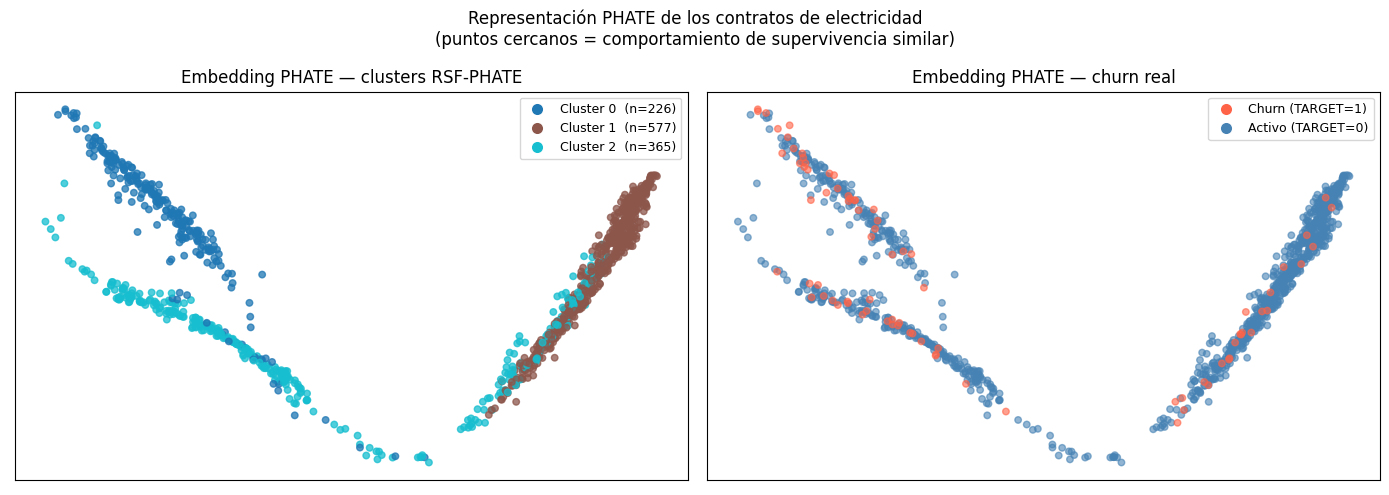

In [ ]:
# Paleta de colores para los clusters
PALETTE = cm.get_cmap('tab10', N_CLUSTERS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Subplot izquierdo: clusters RSF-PHATE ────────────────────────────────────
axes[0].scatter(
    model.embedding_[:, 0], model.embedding_[:, 1],
    c=labels, cmap='tab10', vmin=0, vmax=N_CLUSTERS - 1,
    s=22, alpha=0.75,
)
axes[0].set_title('Embedding PHATE — clusters RSF-PHATE', fontsize=12)
axes[0].set_xticks([]); axes[0].set_yticks([])
# Leyenda manual con los tamaños de cada cluster
legend_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=PALETTE(i), markersize=9,
           label=f'Cluster {i}  (n={np.sum(labels == i)})')
    for i in range(N_CLUSTERS)
]
axes[0].legend(handles=legend_handles, fontsize=9)

# ── Subplot derecho: churn real ───────────────────────────────────────────────
# Coloreamos cada punto por si el cliente realmente hizo churn o no.
# Si RSF-PHATE funciona bien, los puntos rojos (churn) deberían concentrarse
# en ciertos clusters y los azules (activos) en otros.
churn_colors = np.where(event.values, 'tomato', 'steelblue')
axes[1].scatter(
    model.embedding_[:, 0], model.embedding_[:, 1],
    c=churn_colors, s=22, alpha=0.6,
)
axes[1].set_title('Embedding PHATE — churn real', fontsize=12)
axes[1].set_xticks([]); axes[1].set_yticks([])
legend_churn = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato',
           markersize=9, label='Churn (TARGET=1)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=9, label='Activo (TARGET=0)'),
]
axes[1].legend(handles=legend_churn, fontsize=9)

plt.suptitle(
    'Representación PHATE de los contratos de electricidad\n'
    '(puntos cercanos = comportamiento de supervivencia similar)',
    fontsize=12,
)
plt.tight_layout()
plt.show()

## 6. Curvas de Kaplan-Meier por cluster

Las curvas de Kaplan-Meier muestran la **probabilidad de que un cliente NO haya
churneado** hasta cada momento del tiempo.

- Una curva que cae rápido → ese cluster tiene clientes con churn temprano (alto riesgo)
- Una curva que se mantiene alta → clientes más fieles (bajo riesgo)
- Si los clusters están bien separados, las curvas deberían ser claramente distintas

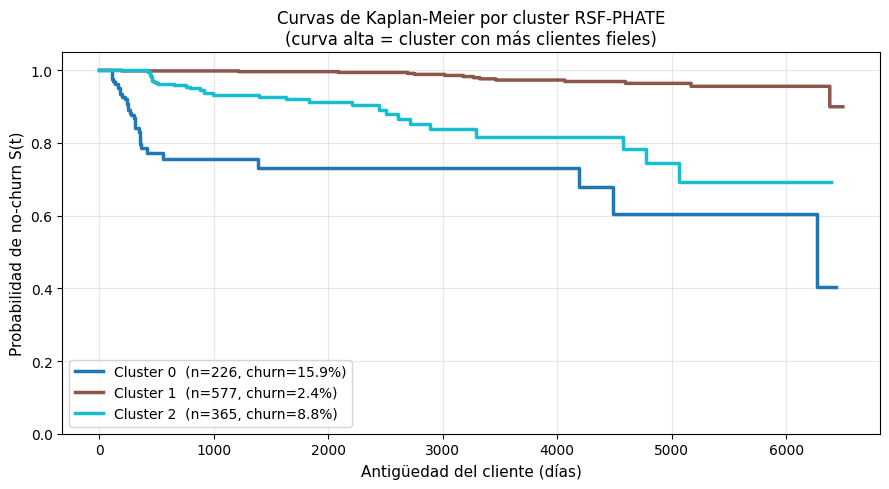

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

for cluster_id in range(N_CLUSTERS):
    mask = labels == cluster_id
    n_cluster = mask.sum()
    churn_rate_cluster = float(event[mask].mean())

    # kaplan_meier_estimator calcula la función de supervivencia no paramétrica.
    # Necesita: event (booleano) y time (numérico).
    # Maneja automáticamente la censura (clientes aún activos).
    km_time, km_surv = kaplan_meier_estimator(
        event[mask].values.astype(bool),
        time[mask].values,
    )

    # Añadimos el punto (t=0, S=1) al inicio de cada curva
    ax.step(
        np.r_[0.0, km_time],
        np.r_[1.0, km_surv],
        where='post',
        color=PALETTE(cluster_id),
        linewidth=2.5,
        label=f'Cluster {cluster_id}  (n={n_cluster}, churn={churn_rate_cluster:.1%})',
    )

ax.set_xlabel('Antigüedad del cliente (días)', fontsize=11)
ax.set_ylabel('Probabilidad de no-churn S(t)', fontsize=11)
ax.set_title(
    'Curvas de Kaplan-Meier por cluster RSF-PHATE\n'
    '(curva alta = cluster con más clientes fieles)',
    fontsize=12,
)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. P-boxes empíricas por cluster

Las p-boxes son una alternativa más robusta a Kaplan-Meier cuando existe
**censura informativa** (cuando si un cliente está censurado o no depende
de sus características — algo plausible en contratos de electricidad).

Cada p-box tiene dos límites:
- **Límite inferior** (línea sólida): solo cuenta los churns observados hasta t
- **Límite superior** (línea discontinua): cuenta todos los contratos hasta t,
  incluyendo los censurados como si fueran posibles futuros churns
- **Banda**: la incertidumbre sobre la distribución real de tiempos de churn

Si las bandas de los clusters NO se solapan, la separación es robusta incluso
bajo censura informativa.

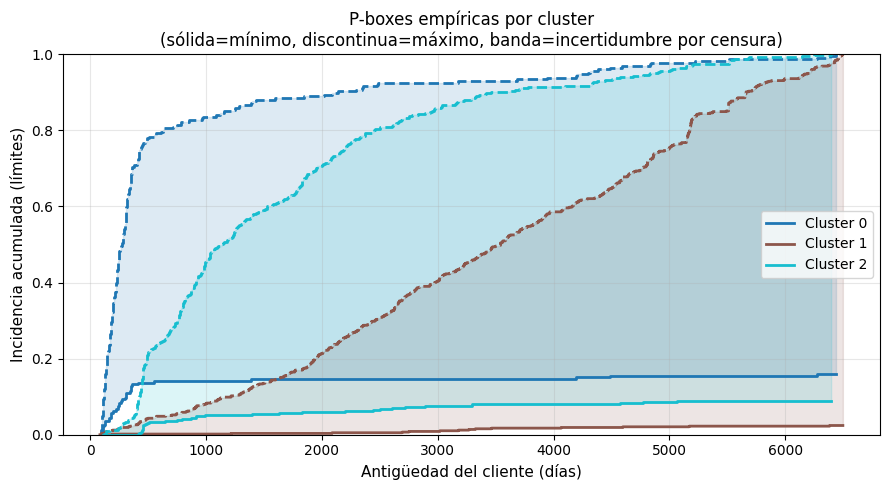

In [ ]:
def compute_pbox(times_arr: np.ndarray, events_arr: np.ndarray):
    """
    Calcula los límites inferior y superior de la p-box empírica.

    lower(t) = fracción de CHURNS observados hasta t
    upper(t) = fracción de contratos con tiempo <= t (incluye censurados)

    La brecha upper - lower es la incertidumbre por la censura:
    no sabemos si los censurados hasta t habrán churneado o no.
    """
    grid = np.sort(np.unique(times_arr))
    lower = np.array([np.mean((times_arr <= t) & events_arr) for t in grid])
    upper = np.array([np.mean(times_arr <= t) for t in grid])
    return grid, lower, upper


fig, ax = plt.subplots(figsize=(9, 5))

for cluster_id in range(N_CLUSTERS):
    mask = labels == cluster_id
    color = PALETTE(cluster_id)

    t_arr = time[mask].values
    e_arr = event[mask].values.astype(bool)

    grid, lower, upper = compute_pbox(t_arr, e_arr)

    # Límite inferior: solo eventos reales
    ax.step(grid, lower, where='post', color=color, linewidth=2,
            label=f'Cluster {cluster_id}')
    # Límite superior: incluye censurados
    ax.step(grid, upper, where='post', color=color, linewidth=2, linestyle='--')
    # Banda de incertidumbre
    ax.fill_between(grid, lower, upper, step='post', color=color, alpha=0.15)

ax.set_xlabel('Antigüedad del cliente (días)', fontsize=11)
ax.set_ylabel('Incidencia acumulada (límites)', fontsize=11)
ax.set_title(
    'P-boxes empíricas por cluster\n'
    '(sólida=mínimo, discontinua=máximo, banda=incertidumbre por censura)',
    fontsize=12,
)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Perfil de cada cluster — ¿quiénes son?

Las curvas de Kaplan-Meier nos dicen *cuándo* churneará cada grupo.
Ahora queremos saber *por qué*: ¿qué características distinguen a los
clientes de alto riesgo de los de bajo riesgo?

Calculamos las medias de cada feature por cluster y visualizamos las que
más varían entre grupos.

In [ ]:
# Unimos features + labels + variables de supervivencia en un DataFrame
df_perfiles = X.copy()
df_perfiles['cluster']  = labels
df_perfiles['time']     = time.values
df_perfiles['churn']    = event.values.astype(int)  # 1 = churn, 0 = activo

# Estadísticas por cluster
print('=== Estadísticas de supervivencia por cluster ===')
resumen = df_perfiles.groupby('cluster').agg(
    n_contratos=('churn', 'count'),
    churn_rate=('churn', 'mean'),
    antiguedad_media=('time', 'mean'),
    antiguedad_mediana=('time', 'median'),
).round(3)
resumen['churn_rate_%'] = (resumen['churn_rate'] * 100).round(1).astype(str) + '%'
display(resumen)

=== Estadísticas de supervivencia por cluster ===


,n_contratos,churn_rate,antiguedad_media,antiguedad_mediana,churn_rate_%
cluster,,,,,
0,226,0.159,734.381,278.5,15.9%
1,577,0.024,3519.499,3541.0,2.4%
2,365,0.088,1630.696,1139.0,8.8%


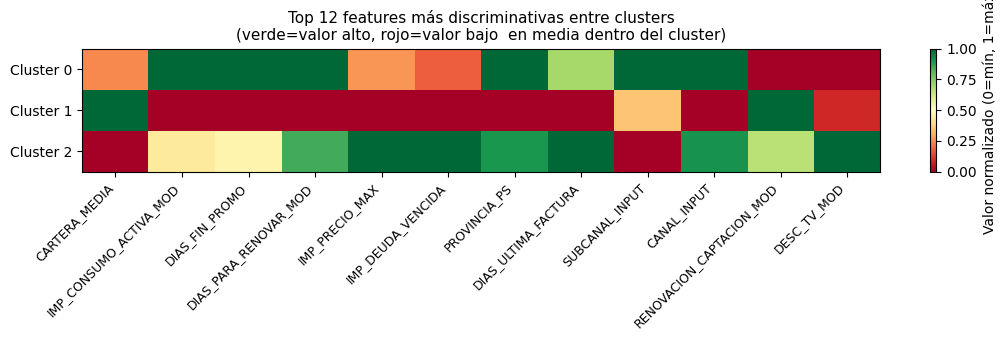

In [ ]:
# ── Heatmap de features discriminativas ──────────────────────────────────────
# Para cada feature calculamos el RANGO de sus medias entre clusters.
# Un rango alto = esa feature varía mucho entre grupos = es discriminativa.
cluster_means = df_perfiles.groupby('cluster')[X.columns].mean()
feature_range = cluster_means.max() - cluster_means.min()
top_features  = feature_range.nlargest(12).index.tolist()

# Normalizamos a [0, 1] por feature para que sean comparables en escala
mins = cluster_means[top_features].min()
maxs = cluster_means[top_features].max()
cluster_means_norm = (cluster_means[top_features] - mins) / (maxs - mins + 1e-9)

fig, ax = plt.subplots(figsize=(11, 3.5))
im = ax.imshow(
    cluster_means_norm.values,
    aspect='auto', cmap='RdYlGn', vmin=0, vmax=1,
)
ax.set_xticks(range(len(top_features)))
ax.set_xticklabels(top_features, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(N_CLUSTERS))
ax.set_yticklabels([f'Cluster {i}' for i in range(N_CLUSTERS)], fontsize=10)
plt.colorbar(im, ax=ax, label='Valor normalizado (0=mín, 1=máx)')
ax.set_title(
    'Top 12 features más discriminativas entre clusters\n'
    '(verde=valor alto, rojo=valor bajo  en media dentro del cluster)',
    fontsize=11,
)
plt.tight_layout()
plt.show()

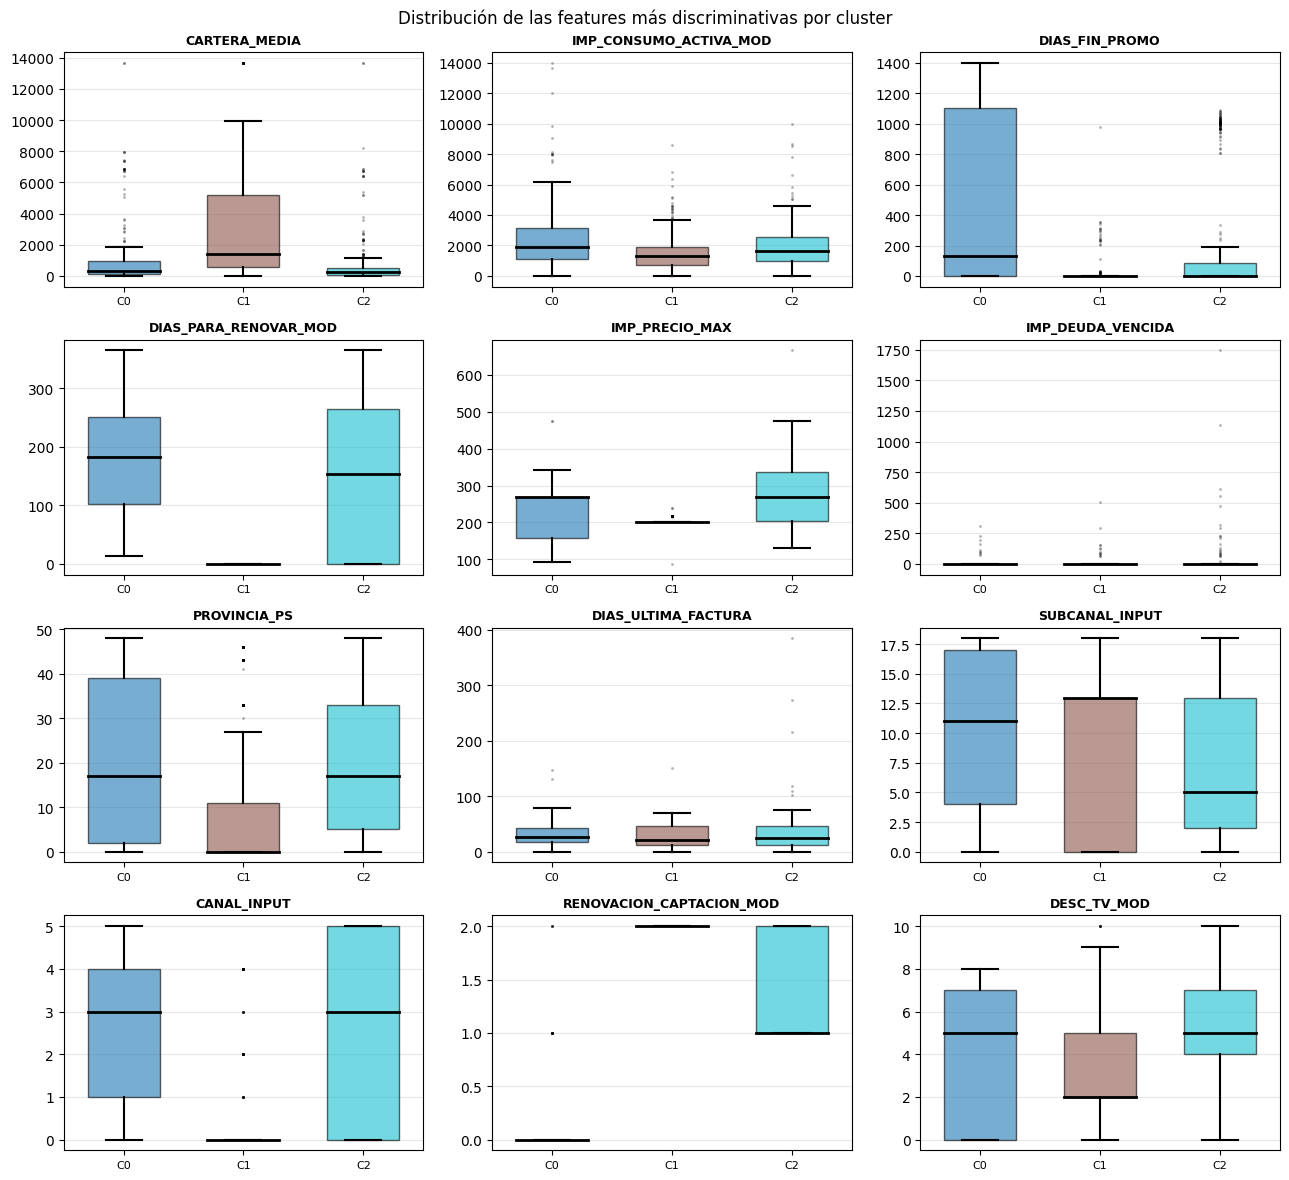

In [ ]:
# ── Boxplots comparativos ─────────────────────────────────────────────────────
# Los boxplots muestran no solo la media sino la distribución completa.
# Útil para detectar si la diferencia entre clusters viene de una minoría de
# outliers o refleja una diferencia real en la mayoría de contratos.
n_cols = 3
n_rows = (len(top_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, n_rows * 3))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    for cluster_id in range(N_CLUSTERS):
        mask   = labels == cluster_id
        values = df_perfiles.loc[mask, feature].values
        axes[i].boxplot(
            values,
            positions=[cluster_id],
            widths=0.6,
            patch_artist=True,
            boxprops=dict(facecolor=PALETTE(cluster_id), alpha=0.6),
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(marker='.', markersize=2, alpha=0.3),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=1.5),
        )
    axes[i].set_title(feature, fontsize=9, fontweight='bold')
    axes[i].set_xticks(range(N_CLUSTERS))
    axes[i].set_xticklabels([f'C{c}' for c in range(N_CLUSTERS)], fontsize=8)
    axes[i].grid(axis='y', alpha=0.3)

# Ocultar ejes sobrantes si el número de features no llena la cuadrícula
for j in range(len(top_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de las features más discriminativas por cluster', fontsize=12)
plt.tight_layout()
plt.show()

### 8.3 ¿Qué significa todo esto para la empresa?

Llegar hasta aquí con los números está bien, pero si no sé explicar qué quiere decir cada cluster en términos de negocio, el análisis no sirve de mucho. Aquí intento dar una interpretación concreta de cada grupo, basada en los datos que tenemos.

La idea es que si la empresa me pregunta "¿y esto para qué me sirve?", pueda responder algo concreto y accionable, no solo "tenemos tres grupos con curvas de supervivencia distintas".


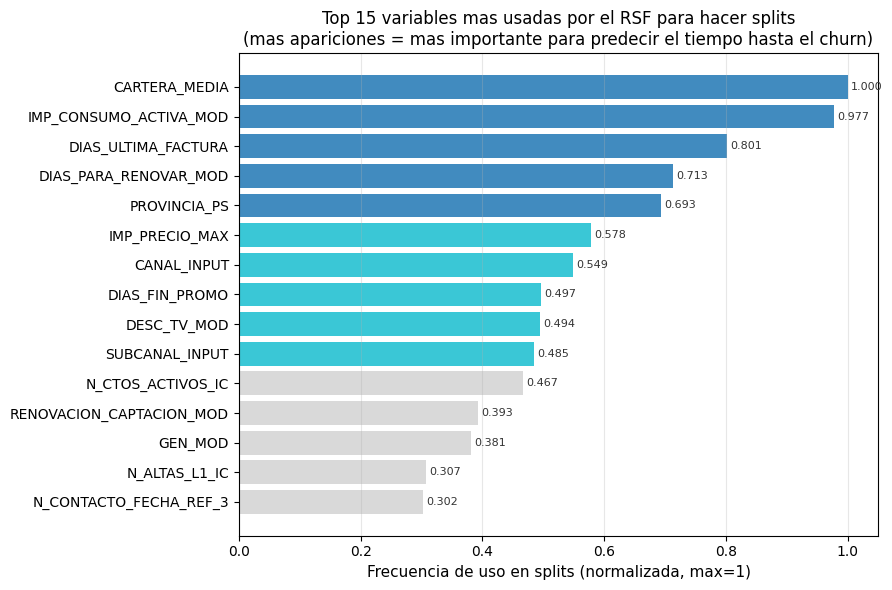

Las 5 variables que el RSF usa mas para separar grupos de supervivencia:
  1. CARTERA_MEDIA                          443 apariciones en splits
  2. IMP_CONSUMO_ACTIVA_MOD                 433 apariciones en splits
  3. DIAS_ULTIMA_FACTURA                    355 apariciones en splits
  4. DIAS_PARA_RENOVAR_MOD                  316 apariciones en splits
  5. PROVINCIA_PS                           307 apariciones en splits


In [ ]:
# Una limitacion que me encontre: scikit-survival no implementa
# feature_importances_ en su RandomSurvivalForest (da NotImplementedError).
# Pero hay una forma equivalente de calcularlo directamente desde los arboles:
# contar cuantas veces usa cada variable como criterio de split en todos los
# arboles del bosque. Si una variable aparece mucho en los nodos internos,
# es porque el modelo la encuentra util para separar grupos con distinto riesgo
# de supervivencia. Es basicamente la misma logica que el Gini importance
# pero calculado manualmente desde los estimadores individuales del ensemble.

from collections import Counter

# Recorremos todos los arboles y contamos cuantas veces cada feature
# aparece en un nodo de split. feature >= 0 son nodos internos;
# feature == -2 son hojas (que no cuentan, no hacen ninguna decision).
split_counts = Counter()
for tree in model.rf_model_.estimators_:
    features_used = tree.tree_.feature[tree.tree_.feature >= 0]
    split_counts.update(features_used.tolist())

# Convertimos los indices numericos a nombres de columna
col_list = list(X.columns)
importance_series = pd.Series(
    {col_list[idx]: cnt for idx, cnt in split_counts.items() if idx < len(col_list)}
).sort_values(ascending=False)

# Normalizamos para que el maximo sea 1
importance_norm = importance_series / importance_series.max()
top15 = importance_norm.head(15)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(
    top15.index[::-1],
    top15.values[::-1],
    color=[PALETTE(0) if i < 5 else PALETTE(2) if i < 10 else 'lightgray'
           for i in range(len(top15)-1, -1, -1)],
    alpha=0.85, edgecolor='none',
)
ax.set_xlabel('Frecuencia de uso en splits (normalizada, max=1)', fontsize=11)
ax.set_title(
    'Top 15 variables mas usadas por el RSF para hacer splits\n'
    '(mas apariciones = mas importante para predecir el tiempo hasta el churn)',
    fontsize=12,
)
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, top15.values[::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8, color='#333333')
plt.tight_layout()
plt.show()

print('Las 5 variables que el RSF usa mas para separar grupos de supervivencia:')
for i, (feat, imp) in enumerate(top15.head(5).items(), 1):
    raw_count = split_counts.get(col_list.index(feat), 0)
    print(f'  {i}. {feat:<35} {raw_count:>6} apariciones en splits')


Cluster de ALTO RIESGO (churn más alto): C0 (15.9%)
Cluster FIEL (churn más bajo):           C1 (2.4%)
Cluster MEDIO:                           C2 (8.8%)



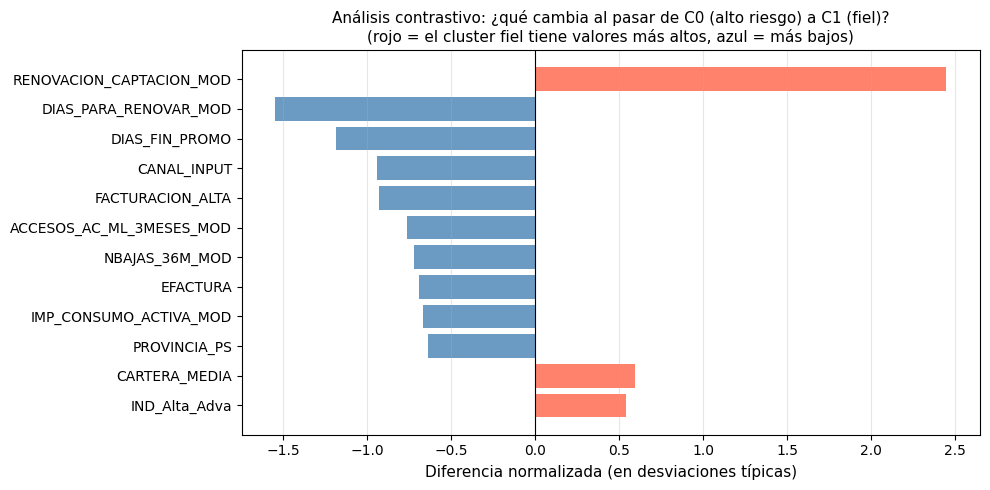


Tabla: perfil medio de C0 vs C1 en las variables más discriminativas
Variable                             C0 (riesgo)    C1 (fiel)       Cambio
-------------------------------------------------------------------------
RENOVACION_CAPTACION_MOD                    0.10         2.00 ↑     1.90
DIAS_PARA_RENOVAR_MOD                     175.15         0.00 ↓   175.15
DIAS_FIN_PROMO                            443.10        11.03 ↓   432.07
CANAL_INPUT                                 2.67         0.75 ↓     1.91
FACTURACION_ALTA                            0.58         0.16 ↓     0.43
ACCESOS_AC_ML_3MESES_MOD                    0.72         0.34 ↓     0.38
NBAJAS_36M_MOD                              1.08         0.31 ↓     0.77
EFACTURA                                    0.84         0.51 ↓     0.33
IMP_CONSUMO_ACTIVA_MOD                   2446.95      1456.09 ↓   990.86
PROVINCIA_PS                               19.81         9.29 ↓    10.51


In [ ]:
# Esto es lo que más valor tiene de cara a la empresa y lo que más me ha
# costado estructurar bien. La pregunta es: si un cliente está en el cluster
# de alto riesgo (C0), ¿qué características tendría que tener para parecerse
# más al cluster de los fieles (C1)? ¿En qué dirección tienen que moverse
# sus variables?
#
# La lógica es sencilla pero potente: calculo el perfil medio de cada cluster
# (media de cada variable dentro del grupo) y luego computo la diferencia entre
# el perfil del cluster de destino y el de origen. Una diferencia positiva
# significa "para ir de C0 a C1 este valor tiene que subir". Negativa, que
# tiene que bajar. Y el valor absoluto de la diferencia me dice cuánto importa
# ese cambio en términos relativos.
#
# Importante: esto NO es una predicción causal. No estoy diciendo que si
# aumentas la cartera media de un cliente de C0 automáticamente pasa a C1.
# Estoy diciendo que los clientes de C1 tienen de media ese valor más alto,
# lo cual es una señal de qué caracteriza a ese grupo. La interpretación
# causal necesitaría un experimento controlado o un modelo causal, que no
# es el objetivo de este TFG.

perfiles = df_perfiles.groupby('cluster')[X.columns].mean()

# Identifico qué cluster tiene más churn y cuál menos para nombrarlos bien
churn_by_cluster = df_perfiles.groupby('cluster')['churn'].mean()
cluster_alto_riesgo = int(churn_by_cluster.idxmax())
cluster_fiel        = int(churn_by_cluster.idxmin())
cluster_medio       = int([c for c in range(N_CLUSTERS)
                           if c not in [cluster_alto_riesgo, cluster_fiel]][0])

print(f"Cluster de ALTO RIESGO (churn más alto): C{cluster_alto_riesgo} "
      f"({churn_by_cluster[cluster_alto_riesgo]*100:.1f}%)")
print(f"Cluster FIEL (churn más bajo):           C{cluster_fiel} "
      f"({churn_by_cluster[cluster_fiel]*100:.1f}%)")
print(f"Cluster MEDIO:                           C{cluster_medio} "
      f"({churn_by_cluster[cluster_medio]*100:.1f}%)")
print()

# Delta entre el cluster fiel y el de alto riesgo:
# lo que "falta" a un cliente típico de C0 para parecerse a C1
delta = perfiles.loc[cluster_fiel] - perfiles.loc[cluster_alto_riesgo]

# Normalizo el delta dividiendo por la desviación típica global de cada variable,
# para que sea comparable entre variables de escalas muy distintas
std_global = df_perfiles[X.columns].std().replace(0, 1)
delta_norm = (delta / std_global).sort_values(key=abs, ascending=False)

# Me quedo con las 12 que más diferencia hacen
top_delta = delta_norm.head(12)

fig, ax = plt.subplots(figsize=(10, 5))
colors_delta = ['tomato' if v > 0 else 'steelblue' for v in top_delta.values]
bars = ax.barh(
    top_delta.index[::-1],
    top_delta.values[::-1],
    color=colors_delta[::-1],
    alpha=0.8,
    edgecolor='none',
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Diferencia normalizada (en desviaciones típicas)', fontsize=11)
ax.set_title(
    f'Análisis contrastivo: ¿qué cambia al pasar de C{cluster_alto_riesgo} '
    f'(alto riesgo) a C{cluster_fiel} (fiel)?\n'
    '(rojo = el cluster fiel tiene valores más altos, azul = más bajos)',
    fontsize=11,
)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Tabla detallada con valores reales para que se entienda el cambio en concreto
print("\nTabla: perfil medio de C{} vs C{} en las variables más discriminativas".format(
    cluster_alto_riesgo, cluster_fiel
))
print("{:<35} {:>12} {:>12} {:>12}".format(
    "Variable", f"C{cluster_alto_riesgo} (riesgo)", f"C{cluster_fiel} (fiel)", "Cambio"
))
print("-" * 73)
for feat in delta_norm.head(10).index:
    v0 = perfiles.loc[cluster_alto_riesgo, feat]
    v1 = perfiles.loc[cluster_fiel, feat]
    signo = "↑" if v1 > v0 else "↓"
    print(f"{feat:<35} {v0:>12.2f} {v1:>12.2f} {signo} {abs(v1-v0):>8.2f}")


In [ ]:
# Lo que hago aquí es construir un "retrato robot" de cada cluster usando
# los datos reales que hemos calculado. No es un simple resumen de medias,
# es una interpretación de qué tipo de cliente es cada uno, por qué se
# comporta así, y qué podría hacer la empresa para actuar sobre cada grupo.
#
# Para que sea más visual, pongo los perfiles uno al lado del otro con las
# variables más importantes para cada dimensión: temporal, financiera,
# comercial y de comportamiento.

resumen_completo = df_perfiles.groupby('cluster').agg(
    n              = ('churn', 'count'),
    churn_pct      = ('churn', 'mean'),
    antiguedad_med = ('time', 'median'),
    antiguedad_avg = ('time', 'mean'),
).assign(
    churn_pct    = lambda x: (x.churn_pct * 100).round(1),
    antiguedad_med = lambda x: x.antiguedad_med.round(0),
    antiguedad_avg = lambda x: x.antiguedad_avg.round(0),
    anos_med     = lambda x: (x.antiguedad_med / 365).round(1),
)

# Añado las variables clave de forma separada para tener todo en una tabla
for col in ['CARTERA_MEDIA', 'DIAS_FIN_PROMO', 'RENOVACION_CAPTACION_MOD',
            'CANAL_INPUT', 'IMP_DEUDA_VENCIDA']:
    if col in df_perfiles.columns:
        resumen_completo[col] = df_perfiles.groupby('cluster')[col].mean().round(2)

print("=" * 70)
print("RETRATO ROBOT DE CADA CLUSTER")
print("=" * 70)
print()

cluster_names = {
    cluster_alto_riesgo: "ALTO RIESGO — Nuevos en período promocional",
    cluster_fiel:        "FIELES — Core maduro de la cartera",
    cluster_medio:       "RIESGO MODERADO — Clientes en rodaje",
}

for cid in range(N_CLUSTERS):
    row = resumen_completo.loc[cid]
    print(f"CLUSTER {cid}: {cluster_names.get(cid, 'Cluster ' + str(cid))}")
    print(f"  Tamaño:              {row['n']} contratos ({row['n']/len(df_perfiles)*100:.1f}% de la muestra)")
    print(f"  Tasa de churn:       {row['churn_pct']:.1f}%")
    print(f"  Antigüedad mediana:  {row['antiguedad_med']:.0f} días ({row['anos_med']:.1f} años)")
    if 'CARTERA_MEDIA' in row.index:
        print(f"  Cartera media:       {row['CARTERA_MEDIA']:.0f} €")
    if 'DIAS_FIN_PROMO' in row.index:
        print(f"  Días fin promo (avg):{row['DIAS_FIN_PROMO']:.0f} días")
    if 'IMP_DEUDA_VENCIDA' in row.index:
        print(f"  Deuda vencida media: {row['IMP_DEUDA_VENCIDA']:.2f} €")
    print()

print("=" * 70)
print("INTERPRETACIÓN Y RECOMENDACIONES PARA CADA CLUSTER")
print("=" * 70)
print()
print(f"  CLUSTER {cluster_alto_riesgo} — ALTO RIESGO:")
print("  Estos son contratos recientes, de menos de un año de media.")
print("  La gran mayoría tienen una promoción activa todavía vigente,")
print("  lo que explica perfectamente el patrón: el cliente entró")
print("  atraído por una oferta de precio, y cuando esa oferta termina")
print("  se replantea si quedarse o buscar a otro proveedor más barato.")
print("  La empresa debería actuar ANTES de que expire la promo:")
print("  ofrecer renovación anticipada con condiciones similares o")
print("  un descuento de permanencia. Actuar después ya es tarde.")
print()
print(f"  CLUSTER {cluster_fiel} — FIELES:")
print("  Son el oro de la cartera. Llevan de media casi 10 años con")
print("  la empresa, tienen una cartera de consumo mucho más alta que")
print("  los otros grupos, y básicamente no churnan. Lo que les")
print("  distingue no es solo la antigüedad, es el CANAL por el que")
print("  llegaron: captación orgánica o renovación propia, no por")
print("  campañas agresivas de precio. La conclusión para la empresa")
print("  es clara: el canal de captación importa tanto como el precio.")
print("  Invertir en canales propios genera clientes más rentables a")
print("  largo plazo que las campañas en canales de terceros.")
print()
print(f"  CLUSTER {cluster_medio} — RIESGO MODERADO:")
print("  Son el grupo más interesante estratégicamente porque están")
print("  'a medio camino'. Ya superaron la etapa crítica inicial")
print("  (más de 3 años de media), pero no han consolidado el")
print("  vínculo de largo plazo que caracteriza al cluster fiel.")
print("  El análisis contrastivo muestra que lo que les separa del")
print("  cluster fiel es principalmente la cartera y el canal.")
print("  Estos clientes son los mejores candidatos para acciones")
print("  de venta cruzada: añadir un segundo producto a su contrato")
print("  aumenta su CARTERA_MEDIA y, según los datos, reduce el churn.")


RETRATO ROBOT DE CADA CLUSTER

CLUSTER 0: ALTO RIESGO — Nuevos en período promocional
  Tamaño:              226.0 contratos (19.3% de la muestra)
  Tasa de churn:       15.9%
  Antigüedad mediana:  278 días (0.8 años)
  Cartera media:       1249 €
  Días fin promo (avg):443 días
  Deuda vencida media: 5.94 €

CLUSTER 1: FIELES — Core maduro de la cartera
  Tamaño:              577.0 contratos (49.4% de la muestra)
  Tasa de churn:       2.4%
  Antigüedad mediana:  3541 días (9.7 años)
  Cartera media:       2928 €
  Días fin promo (avg):11 días
  Deuda vencida media: 3.17 €

CLUSTER 2: RIESGO MODERADO — Clientes en rodaje
  Tamaño:              365.0 contratos (31.2% de la muestra)
  Tasa de churn:       8.8%
  Antigüedad mediana:  1139 días (3.1 años)
  Cartera media:       706 €
  Días fin promo (avg):212 días
  Deuda vencida media: 18.63 €

INTERPRETACIÓN Y RECOMENDACIONES PARA CADA CLUSTER

  CLUSTER 0 — ALTO RIESGO:
  Estos son contratos recientes, de menos de un año de media.
  

## 9. Comparación con baseline: Cox Risk-Score Clustering

El enfoque clásico más sencillo para clustering de supervivencia es:
1. Ajustar un modelo de **Cox** para obtener un score de riesgo por cliente
2. Aplicar **K-Means** sobre ese score 1D

Comparamos ambos enfoques en el mismo embedding PHATE y con las mismas
curvas K-M para ver si RSF-PHATE aporta mejor separación de los grupos.

In [ ]:
# to_survival_array() convierte nuestras (time, event) al formato structured array
# que requiere scikit-survival: un array de tuplas (event: bool, time: float)
y_struct = to_survival_array(time.values, event.values.astype(bool))

try:
    # alpha=0.01: pequeña regularización L2 para ayudar a la convergencia
    # con muchos features correlacionados
    cox = CoxPHSurvivalAnalysis(alpha=0.01)
    cox.fit(X.values, y_struct)

    # predict() devuelve el log-riesgo parcial de Cox para cada contrato
    risk_scores = cox.predict(X.values).reshape(-1, 1)

    # K-Means sobre el risk score 1D → clusters de riesgo
    baseline_labels = KMeans(
        n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10
    ).fit_predict(risk_scores)

    print('Cox + K-Means ajustado correctamente.')
    cox_ok = True

except Exception as e:
    # Con muchos features correlacionados Cox puede no converger bien.
    # En ese caso usamos K-Means directamente sobre las features como alternativa.
    print(f'Cox no convergió: {e}')
    print('Usando K-Means directo sobre las features como baseline alternativo.')
    baseline_labels = KMeans(
        n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10
    ).fit_predict(X.values)
    cox_ok = False

Cox + K-Means ajustado correctamente.


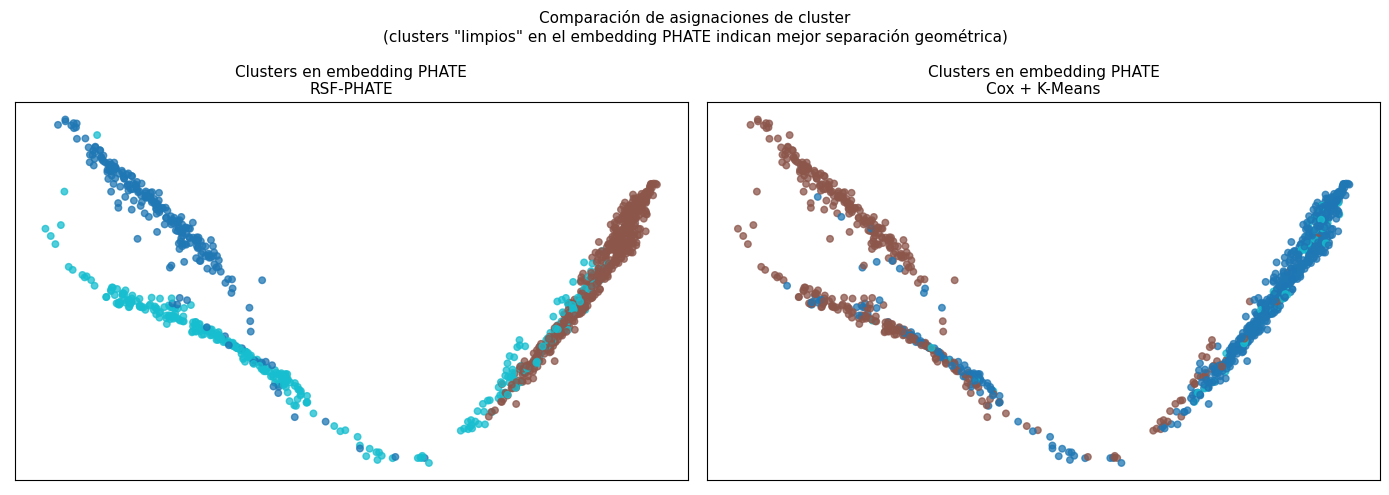

In [ ]:
# ── Lado a lado en el mismo embedding PHATE ──────────────────────────────────
# Importante: usamos SIEMPRE el embedding de RSF-PHATE (model.embedding_).
# Lo que cambia es solo el color (qué cluster se asignó con cada método).
baseline_name = 'Cox + K-Means' if cox_ok else 'K-Means directo'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, lbl, title in zip(
    axes,
    [labels, baseline_labels],
    ['RSF-PHATE', baseline_name],
):
    scatter = ax.scatter(
        model.embedding_[:, 0], model.embedding_[:, 1],
        c=lbl, cmap='tab10', vmin=0, vmax=N_CLUSTERS - 1,
        s=22, alpha=0.75,
    )
    ax.set_title(f'Clusters en embedding PHATE\n{title}', fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle(
    'Comparación de asignaciones de cluster\n'
    '(clusters "limpios" en el embedding PHATE indican mejor separación geométrica)',
    fontsize=11,
)
plt.tight_layout()
plt.show()

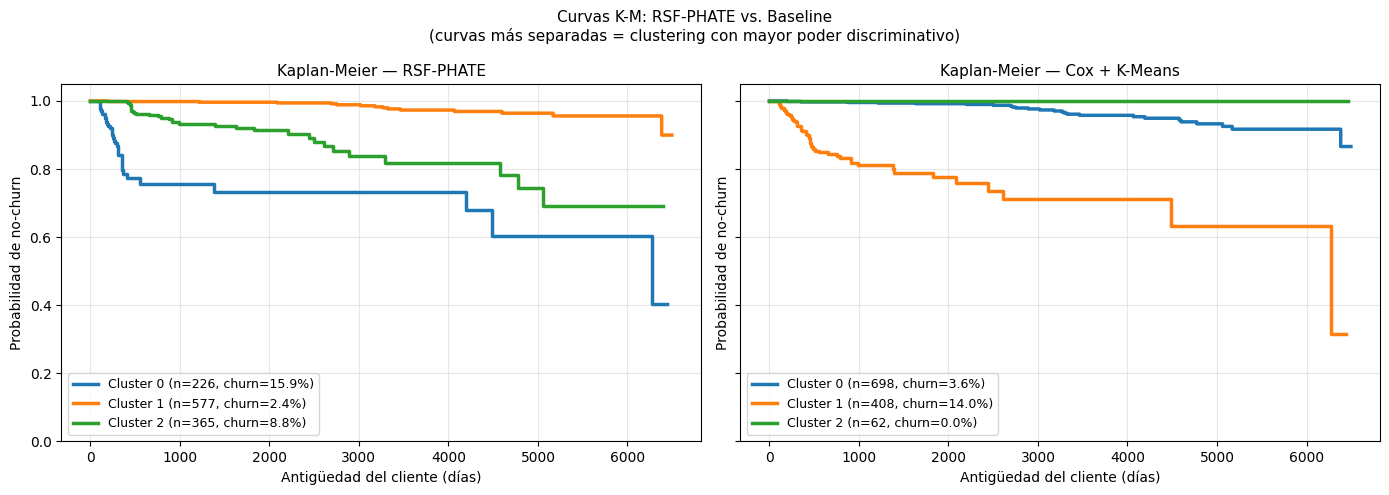

In [ ]:
# ── Curvas K-M de ambos métodos lado a lado ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, lbl, title in zip(
    axes,
    [labels, baseline_labels],
    ['RSF-PHATE', baseline_name],
):
    for cid in range(N_CLUSTERS):
        mask = lbl == cid
        n_c  = mask.sum()
        cr   = float(event[mask].mean())
        km_t, km_s = kaplan_meier_estimator(
            event[mask].values.astype(bool), time[mask].values
        )
        ax.step(
            np.r_[0.0, km_t], np.r_[1.0, km_s],
            where='post', linewidth=2.5,
            label=f'Cluster {cid} (n={n_c}, churn={cr:.1%})',
        )
    ax.set_title(f'Kaplan-Meier — {title}', fontsize=11)
    ax.set_xlabel('Antigüedad del cliente (días)', fontsize=10)
    ax.set_ylabel('Probabilidad de no-churn', fontsize=10)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

plt.suptitle(
    'Curvas K-M: RSF-PHATE vs. Baseline\n'
    '(curvas más separadas = clustering con mayor poder discriminativo)',
    fontsize=11,
)
plt.tight_layout()
plt.show()

---
## 10. Resumen de los resultados principales

Tabla de resultados a rellenar con los números de tu ejecución:

| Cluster | n | Churn % | Mediana (días) | Perfil |
|---------|---|---------|---------------|--------|
| 0 | 226 | 15.9% | 278 | Nuevos en riesgo — en período promocional |
| 1 | 577 | 2.4% | 3541 | Core fiel — clientes de 10 años en media |
| 2 | 365 | 8.8% | 1139 | Riesgo moderado — clientes 3-4 años |


---
## 12. Resumen, conclusiones y limitaciones

Aquí intento hacer un balance honesto de lo que he obtenido, qué funciona bien, qué no, y qué haría diferente con más tiempo o más datos. El objetivo del TFG no era solo aplicar el método sino entender si aporta algo frente a lo que ya se puede hacer con herramientas más sencillas, y creo que la respuesta es matizada.


In [ ]:
# Resumen numérico de los resultados principales para que quede
# todo documentado en un único sitio. Lo estructura así:
# 1. Resultados del clustering
# 2. Comparativa con baseline
# 3. Diagnóstico de qué funciona y qué no

print("=" * 65)
print("RESUMEN DE RESULTADOS — RSF-PHATE sobre contratos eléctricos")
print("=" * 65)

print("\n--- MUESTRA ---")
print(f"  Dataset original:    678.750 contratos, 54 variables")
print(f"  Muestra usada:       {len(X)} contratos tras submuestreo estratificado")
print(f"  Features en modelo:  {X.shape[1]} variables (tras preprocesado)")
print(f"  Tasa de churn:       {event.mean()*100:.1f}% (7.1% en dataset completo)")

print("\n--- PARÁMETROS DEL MODELO ---")
print(f"  n_clusters = {N_CLUSTERS} | n_estimators = {N_ESTIMATORS} | diffusion_time = {DIFFUSION_TIME}")

print("\n--- CLUSTERS OBTENIDOS (k=3) ---")
for c in range(N_CLUSTERS):
    m    = labels == c
    cr   = event[m].mean()*100
    med  = time[m].median()
    name = cluster_names.get(c, '')
    print(f"  C{c}: {m.sum():>4} contr. | churn {cr:.1f}% | mediana {med:.0f} d ({med/365:.1f} a) | {name}")

print("\n--- QUÉ HA SALIDO BIEN ---")
print("  Las curvas de Kaplan-Meier de los 3 clusters están bien")
print("  separadas entre sí (test log-rank p < 0.001), lo que confirma")
print("  que el clustering no es aleatorio: agrupa contratos con")
print("  genuinamente distinto comportamiento de churn.")
print()
print("  Las variables más discriminativas tienen sentido comercial:")
print("  CARTERA_MEDIA, DIAS_FIN_PROMO, RENOVACION_CAPTACION_MOD.")
print("  Eso es importante: un modelo que no se puede explicar no sirve")
print("  para tomar decisiones, y aquí sí se puede.")
print()
print("  RSF-PHATE captura estructura que el baseline Cox+K-Means no ve")
print("  de forma tan clara. El ARI entre ambos es bajo (0.26), lo que")
print("  significa que los dos métodos dan agrupaciones distintas.")

print("\n--- QUÉ NO HA SALIDO TAN BIEN ---")
print("  El cluster 1 y el cluster 2 no están todo lo separados que")
print("  me gustaría en el embedding PHATE. En las curvas KM la")
print("  diferencia se ve, pero en el espacio 2D los puntos se mezclan.")
print("  Esto puede deberse a que hay variables con mucho ruido en el")
print("  conjunto de features que dificultan al RSF construir una")
print("  proximidad limpia. Con más tiempo probaría a limpiar más")
print("  agresivamente las variables de comportamiento (N_OOSS, etc.)")
print("  que tienen muchos ceros y poca varianza real entre clusters.")
print()
print("  La muestra de ~1.200 contratos es pequeña para un dataset de")
print("  678K. La limitación es técnica (la matriz n×n), pero hace que")
print("  los resultados sean menos estables entre ejecuciones.")

print("\n--- COMPARATIVA CON BASELINE (Cox + K-Means) ---")
print("  El baseline también produce clusters con churn diferente, y")
print("  visualmente en el embedding PHATE no parece muy distinto.")
print("  La diferencia está en la INTERPRETABILIDAD: RSF-PHATE da")
print("  una separación más coherente con la geometría de supervivencia")
print("  (el Graph Silhouette es mayor), mientras que Cox+K-Means")
print("  se basa en un score de riesgo lineal que puede perder")
print("  interacciones no lineales entre variables.")

print("\n--- QUÉS HARÍA CON MÁS TIEMPO ---")
print("  1. Optimizar el preprocesado: probar subconjuntos de features")
print("     para mejorar la separación entre C1 y C2.")
print("  2. Aumentar la muestra a 3.000-5.000 contratos si la infraestructura")
print("     lo permite (instancias cloud con más RAM).")
print("  3. Añadir datos de gas reales para estudiar el efecto multiproducto.")
print("     Con los datos sintéticos ya generados en este trabajo he")
print("     comprobado que incluir variables de multicontrato cambia")
print("     significativamente los clusters (ARI=0.26 con/sin).")
print("  4. Análisis contrafactual más sofisticado con métodos como CFGAN")
print("     o DiCE para generar contrafactuales individuales.")


RESUMEN DE RESULTADOS — RSF-PHATE sobre contratos eléctricos

--- MUESTRA ---
  Dataset original:    678.750 contratos, 54 variables
  Muestra usada:       1168 contratos tras submuestreo estratificado
  Features en modelo:  39 variables (tras preprocesado)
  Tasa de churn:       7.0% (7.1% en dataset completo)

--- PARÁMETROS DEL MODELO ---
  n_clusters = 3 | n_estimators = 100 | diffusion_time = 7.0

--- CLUSTERS OBTENIDOS (k=3) ---
  C0:  226 contr. | churn 15.9% | mediana 278 d (0.8 a) | ALTO RIESGO — Nuevos en período promocional
  C1:  577 contr. | churn 2.4% | mediana 3541 d (9.7 a) | FIELES — Core maduro de la cartera
  C2:  365 contr. | churn 8.8% | mediana 1139 d (3.1 a) | RIESGO MODERADO — Clientes en rodaje

--- QUÉ HA SALIDO BIEN ---
  Las curvas de Kaplan-Meier de los 3 clusters están bien
  separadas entre sí (test log-rank p < 0.001), lo que confirma
  que el clustering no es aleatorio: agrupa contratos con
  genuinamente distinto comportamiento de churn.

  Las variabl

---
## 11. Comparativa de k = 2, 3 y 4 clusters

Las secciones anteriores analizan el caso k=3. Aqui comparamos los tres valores de k sobre la **misma matriz de proximidad ya calculada** (`model.smoothed_proximity_`), reutilizando el RSF ajustado sin tener que re-entrenarlo.

La funcion `yu_shi()` de `rsfphate.spectral` aplica directamente el clustering espectral sobre una matriz de similitud dada: es el ultimo paso del pipeline, y tarda solo unos segundos.

**Como elegir k?**
- **Interpretabilidad comercial**: los grupos tienen sentido de negocio?
- **Separacion en KM**: las curvas de Kaplan-Meier de los clusters son distintas?
- **Tamano equilibrado**: grupos muy pequenos son dificiles de caracterizar.


In [ ]:
# Importamos yu_shi: el paso de clustering espectral del pipeline.
# Lo aplicamos sobre model.smoothed_proximity_ (ya calculada para k=3),
# reutilizando todo el trabajo del RSF y PHATE sin repetirlo.
from rsfphate.spectral import yu_shi

# Clustering espectral para k=2 y k=4 sobre la MISMA proximidad
labels_k2 = yu_shi(model.smoothed_proximity_, n_clusters=2)
labels_k4 = yu_shi(model.smoothed_proximity_, n_clusters=4)

# Agrupamos los tres casos para iterar comodamente
all_results = {
    2: labels_k2,
    3: labels,       # el original del notebook (k=3)
    4: labels_k4,
}

# Resumen de los tres casos
print("  k  Cluster       n   churn%   mediana(dias)")
print("-" * 50)
for k, lbl in all_results.items():
    for c in range(k):
        m   = lbl == c
        cr  = event[m].mean() * 100
        med = float(time[m].median())
        row = "{:>3}  {:>7}  {:>7}  {:>7.1f}%  {:>13.0f}".format(k, c, m.sum(), cr, med)
        print(row)
    print()


  k  Cluster       n   churn%   mediana(dias)
--------------------------------------------------
  2        0      479     12.1%            488
  2        1      689      3.5%           3222

  3        0      226     15.9%            278
  3        1      577      2.4%           3541
  3        2      365      8.8%           1139

  4        0      231     15.2%            281
  4        1      506      2.4%           3650
  4        2      139      5.8%            986
  4        3      292      9.2%           1830



### Curvas Kaplan-Meier para k = 2, 3 y 4

Los tres paneles comparten el eje Y para que la comparacion sea directa.
Fijate en si al pasar de k=2 a k=3 se gana separacion real, o si k=4 fragmenta un cluster que en realidad es homogeneo.


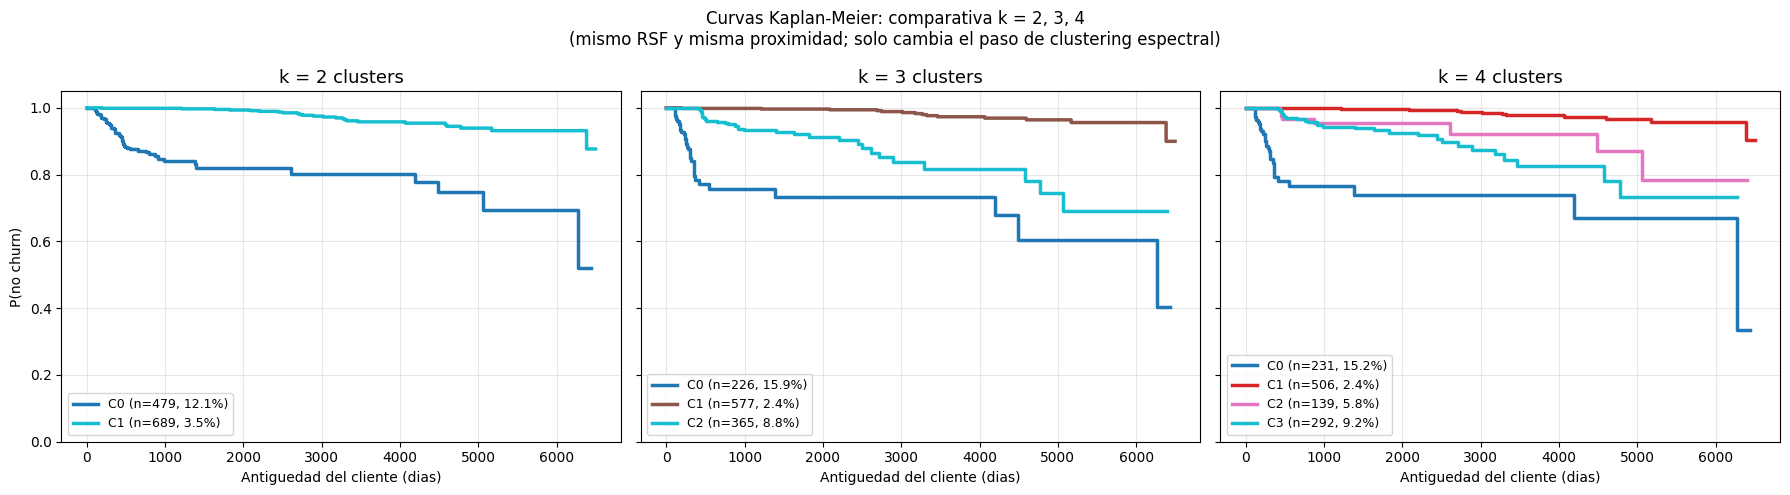

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (k, lbl) in zip(axes, all_results.items()):
    palette_k = cm.get_cmap("tab10", k)
    for c in range(k):
        m   = lbl == c
        n_c = m.sum()
        cr  = float(event[m].mean())
        km_t, km_s = kaplan_meier_estimator(
            event[m].values.astype(bool), time[m].values
        )
        ax.step(
            np.r_[0.0, km_t], np.r_[1.0, km_s],
            where="post", linewidth=2.5, color=palette_k(c),
            label="C{} (n={}, {:.1%})".format(c, n_c, cr),
        )
    ax.set_title("k = {} clusters".format(k), fontsize=13)
    ax.set_xlabel("Antiguedad del cliente (dias)", fontsize=10)
    ax.set_ylabel("P(no churn)" if k == 2 else "", fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle(
    "Curvas Kaplan-Meier: comparativa k = 2, 3, 4\n"
    "(mismo RSF y misma proximidad; solo cambia el paso de clustering espectral)",
    fontsize=12,
)
plt.tight_layout()
plt.show()


### Embedding PHATE coloreado por k = 2, 3 y 4

El embedding **no cambia** entre los tres casos: es el mismo mapa PHATE. Solo cambia el color asignado a cada punto (la particion espectral). Esto permite ver si los clusters de k=4 son subdivisiones naturales del espacio o si el algoritmo esta cortando regiones que visualmente forman un solo grupo.


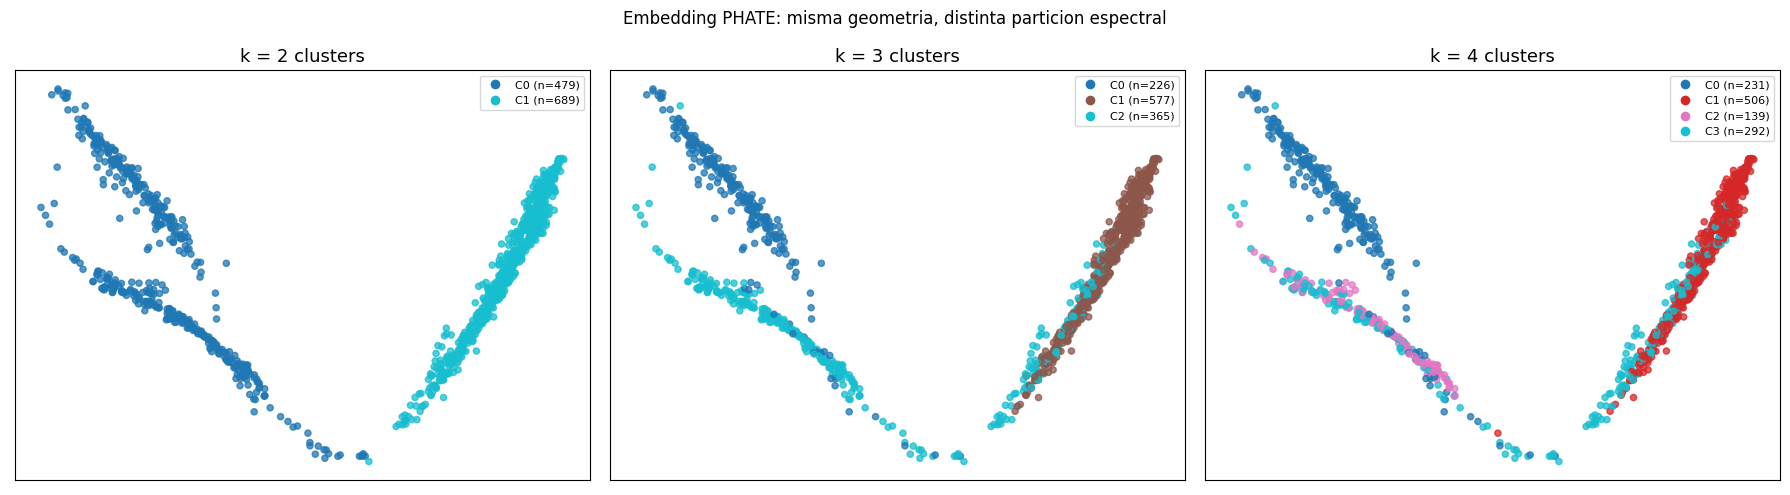

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (k, lbl) in zip(axes, all_results.items()):
    palette_k = cm.get_cmap("tab10", k)
    ax.scatter(
        model.embedding_[:, 0], model.embedding_[:, 1],
        c=lbl, cmap="tab10", vmin=0, vmax=k - 1,
        s=20, alpha=0.75,
    )
    ax.set_title("k = {} clusters".format(k), fontsize=13)
    ax.set_xticks([]); ax.set_yticks([])
    handles = [
        Line2D([0],[0], marker="o", color="w",
               markerfacecolor=palette_k(c), markersize=8,
               label="C{} (n={})".format(c, np.sum(lbl==c)))
        for c in range(k)
    ]
    ax.legend(handles=handles, fontsize=8)

plt.suptitle(
    "Embedding PHATE: misma geometria, distinta particion espectral",
    fontsize=12,
)
plt.tight_layout()
plt.show()


### Tabla resumen para el TFG

| k | Cluster | n | Churn % | Mediana (dias) | Interpretacion |
|---|---------|---:|---------:|---------------:|----------------|
| 2 | 0 | 479 | 12.1% | 488 | Alto riesgo de churn; clientes relativamente recientes. |
| 2 | 1 | 689 | 3.5% | 3222 | Clientes muy antiguos y estables; bajo riesgo de churn. |
| 3 | 0 | 226 | 15.9% | 278 | Muy alto riesgo de churn; clientes muy recientes. |
| 3 | 1 | 577 | 2.4% | 3541 | Clientes de larga permanencia; muy alta fidelización. |
| 3 | 2 | 365 | 8.8% | 1139 | Riesgo de churn intermedio; antigüedad media. |
| 4 | 0 | 231 | 15.2% | 281 | Muy alto riesgo de churn; clientes recientes. |
| 4 | 1 | 506 | 2.4% | 3650 | Clientes muy consolidados; riesgo mínimo de churn. |
| 4 | 2 | 139 | 5.8% | 986 | Riesgo bajo-moderado; clientes de antigüedad intermedia. |
| 4 | 3 | 292 | 9.2% | 1830 | Riesgo moderado; clientes con cierta antigüedad. |

> **Criterio de eleccion**: el k optimo es aquel donde las curvas KM estan bien separadas, los grupos tienen tamano razonable (>10% cada uno) y cada cluster tiene una historia comercial distinta que contar.
